In [7]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ast
import sklearn
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

In [8]:
class TRIAL:
    smoothing_window = 20 #used by self.get_framerate

    @staticmethod
    def get_xz(str):
        # takes in a string '(1,4,7)' and returns a tuple containing only the x and z coordinates [1,7]
        # used for preparing position data
        data = ast.literal_eval(str)
        xz = np.array([data[0], data[2]])
        return xz
    
    
    def __init__(self, filename):
        self.gather(filename)

    def __repr__(self):
        return self.name

    def gather(self, filename):
        full_path = str(filename)
        file_name_with_ext = full_path.split('/')[-1]
        self.name = file_name_with_ext.split('.')[0]
        # [self.participant, self.scenario, self.AV_type] = self.name.split('_')
        parts = self.name.split('_')

        self.participant = parts[0]
        self.scenario = parts[1]
        self.AV_type = '_'.join(parts[2:])

        df = pd.read_csv(filename)

        x_H_col = df['A car Pos'].values
        x_AV_col = df['0 car Pos'].values
    
        self.time = np.array(df['ScenarioTime'].values)
        self.pedal = np.array(df['A accel'].values)
        self.steer = np.array(df['A steering'].values)
        self.x_H = np.array([self.get_xz(pos) for pos in x_H_col])
        self.x_AV = np.array([self.get_xz(pos) for pos in x_AV_col])

        

    def get_framerate(self):
        n = len(self.time)
        self.average_framerate = n / self.time[-1]

        self.framerates = []

        for i in range(n-self.smoothing_window):
            current_t = self.time[i]
            later_t = self.time[i + self.smoothing_window]
            self.framerates.append(self.smoothing_window/(later_t - current_t))

    def plot_framerate(self):
        self.get_framerate()

        end_time = self.time[-self.smoothing_window]
        avg_fr = self.average_framerate

        plt.plot(self.time[:-self.smoothing_window], self.framerates)
        plt.plot([0,end_time],[avg_fr,avg_fr])  #plots a horizontal line showing average framerate
        plt.xlabel('time (s)')
        plt.ylabel('framerate (Hz)')
        plt.xlim(0,30)
        plt.show()

    def plot_time_step_hist(self):
        plt.hist(np.diff(self.time), 35)
        plt.xlabel("time difference between consecutive sample times (s)")
        plt.ylabel("count")
        plt.show()
        
    def plot_paths(self):

        xH = self.x_H
        xAV = self.x_AV
        
        fig, ax = plt.subplots(figsize=(4,4))
        # draw roads
        # assume lane width of 3 for now
        w = 3
        size = 60
        ax.set_xlim(-size,size)
        ax.set_ylim(-size,size)
        rect_V = patches.Rectangle((-w, -size), 2*w, 2*size, facecolor='gray', alpha=0.3)
        rect_H1 = patches.Rectangle((-size,-w), size-w, 2*w, facecolor = 'gray', alpha = 0.3)
        rect_H2 = patches.Rectangle((w,-w),size-w,2*w, facecolor = 'gray', alpha = 0.3)
        ax.add_patch(rect_V)
        ax.add_patch(rect_H1)
        ax.add_patch(rect_H2)
        
        # plot paths
        ax.plot(xH[:,0],xH[:,1], color = 'r', label='H')
        ax.plot(xAV[:,0], xAV[:,1], color = 'b', label='AV')
        ax.legend()

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(self.name)
        
        plt.show()

    def plot_story(self):
        
        time = self.time
        x_H = self.x_H
        x_AV = self.x_AV
        u_H = self.pedal
        
        dist_H = [np.linalg.norm(xi) for xi in x_H]
        dist_AV = [np.linalg.norm(xi) for xi in x_AV]

        t_min = 2. # find more interesting ways to set these
        t_max = min(40, time[-1]-2)
        
        fig, ax = plt.subplots(2,1)
        ax[0].set_xlim(t_min, t_max)
        ax[0].scatter(time, dist_H, label = "Human", color = "red", s = 3)
        ax[0].scatter(time, dist_AV, label = "AV", color = "blue", s = 3)

        # ax[0].set_xlabel('Time (s)')
        ax[0].set_ylabel('Distance to Intersection (m)')
        ax[0].legend()
        ax[0].set_title(self.name)
           
        ax[1].set_xlim(t_min, t_max)
        ax[1].scatter(time, u_H, label='brake/gas', color = 'orange', s = 3)
        ax[1].set_xlabel('Time (s)')
        ax[1].set_ylabel('Pedal')
        ax[1].legend()

        plt.show()

    @staticmethod
    def good_atan(vx,vy):
        return np.atan(vy/vx) if np.abs(vy) < np.abs(vx) else np.sign(vx)*np.sign(vy) * np.pi / 2 - np.atan(vx/vy)
        # this function handles vertical angles just as well as it does horizontal ones
    
    @staticmethod
    def fix_theta(array):
        for i in range(len(array)):
            if i == 0: continue
            if array[i-1] > 1 and array[i] < -1:
                array[i] += np.pi
            if array[i-1] < -1 and array[i] > 1:
                array[i] -= np.pi

        
    def angle_from_velocity(self, vx,vy):
        n = len(vx)
        i = 0
        result = []
        while i < n:
            curr_vx = vx[i]
            curr_vy = vy[i]
            j = 0
            while curr_vx**2 + curr_vy**2 < 0.001:
                j+=1
                if i+j == n:
                    old_theta = result[-1]
                    for k in range(j):
                        result.append(old_theta)
                    self.fix_theta(result)
                    return np.array(result)
                curr_vx = vx[i+j]
                curr_vy = vy[i+j]
            if j>0:
                if i==0:
                    for k in range(j):    
                        result.append(self.good_atan(curr_vx,curr_vy))
                else:
                    old_theta = result[-1]
                    new_theta = self.good_atan(curr_vx,curr_vy)
                    if old_theta > 1 and new_theta < -1:
                        new_theta += np.pi
                    if old_theta < -1 and new_theta > 1:
                        new_theta -= np.pi
                    for k in range(j):
                        result.append(((k+1)/j)*(new_theta - old_theta) + old_theta)
                i += j-1
            else:
                result.append(self.good_atan(curr_vx,curr_vy))
            i+=1
        self.fix_theta(result)
        return np.array(result)
                    

    def get_kinematics(self):
        
        time = self.time
        x_H = self.x_H

        vx_H = np.gradient(x_H[:,0], time)
        vy_H = np.gradient(x_H[:,1], time)
        v_H = np.vstack((vx_H, vy_H)).T
        self.s_H = np.array([np.linalg.norm(vi) for vi in v_H])

        self.theta_H = self.angle_from_velocity(vx_H, vy_H)
        self.omega_H = np.gradient(self.theta_H, time)
        self.a_H = np.gradient(self.s_H, time)
        
    def plot_kinematics(self):
        
        
        time = self.time
        x_H = self.x_H
        pedal = self.pedal[:len(time)]
        steer = self.steer[:len(time)]

        self.get_kinematics()
        
        t_min = 2. # find more interesting ways to set these
        t_max = min(30, time[-1]-2)


        dist_H = [np.linalg.norm(xi) for xi in x_H]
                
        fig, ax = plt.subplots(3,1)
        ax[0].set_xlim(t_min, t_max)
        ax[0].set_ylim(-1.3,1.3)
        ax[0].scatter(time, self.omega_H, label = "Human", color = "red", s = 3)
        ax[0].set_ylabel('theta dot')
        ax[0].set_title(self.name)
           
        ax[1].set_xlim(t_min, t_max)
        ax[1].scatter(time, steer, color = 'orange', s = 3)
        ax[1].set_xlabel('Time (s)')
        ax[1].set_ylabel('steer')

        model = 0.3*np.array(self.s_H) * np.tan(steer*-1)
        ax[2].set_xlim(t_min, t_max)
        ax[2].set_ylim(-1.2,1.2)
        ax[2].scatter(time, self.omega_H, color = "blue", s = 3)
        ax[2].scatter(time, model, color = 'orange', s = 3)
        ax[2].set_ylabel('error')

        plt.show()
        
    def get_vdot(self):

        v_dot = dict()
        
        self.get_kinematics()
        s = self.s_H
        pedal = self.pedal
        a = self.a_H

        for i in range(len(self.time)):
            tup = (pedal[i],s[i])
            if tup in v_dot:
                if np.abs(v_dot[tup] - a[i]) > 0.01:
                    continue
                    # print('collision!', tup, v_dot[tup], a[i])
            v_dot[tup] = a[i]
    
        return v_dot



In [9]:
# trial = TRIAL('../driverdata_cleaned/45_5_Static-Yield.csv')
trial = TRIAL('driverdata_cleaned/16_5_Static-Yield.csv')
# trial = TRIAL('../bad_files/45_5_Static-Yield.csv', 'intersection')

# trial.plot_paths()
# trial.plot_story()
# trial.plot_time_step_hist()
# trial.plot_framerate()
# trial.plot_kinematics()
# d = trial.get_vdot()
# print(5)


In [10]:
class DATA:
    def __init__(self, path):

        csv_files = glob.glob(os.path.join(path, '*.csv'))
        
        self.VDOT = dict()
        
        for file in csv_files:
            trial = TRIAL(file)
            self.VDOT |= trial.get_vdot()

        self.pedal = []
        self.speed = []
        self.accel = []
        for point in self.VDOT:
            self.pedal.append(point[0])
            self.speed.append(point[1])
            self.accel.append(self.VDOT[point])

    
    
folder_path = r'C:\Users\trazo\Downloads\CS 506 Computational Geometry\CS-506-Project-master\driverdata_cleaned'  # change to your folder

X = DATA(folder_path)

In [11]:
from scipy.cluster.hierarchy import DisjointSet
from scipy.spatial import Delaunay
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon
from shapely.plotting import plot_polygon
from sklearn.preprocessing import StandardScaler
from scipy.spatial import Voronoi, voronoi_plot_2d


class ANALYSIS:
    def __init__(self, DATA):
        self.speed = DATA.speed
        self.pedal = DATA.pedal
        self.accel = DATA.accel

        self.X = np.column_stack((self.speed, self.pedal))

        self.scaler = StandardScaler() # Normalize the Data for better looking clusters 
        self.X_scaled = self.scaler.fit_transform(self.X)


    def plot_points(self):

        self.points = np.vstack((self.speed, self.pedal)).T

        plt.figure(figsize=(8,8))
        plt.scatter(self.speed, self.pedal, c=self.accel, cmap='viridis', s= 0.5)
        plt.xlabel('speed (m/s)')
        plt.ylabel('pedal')
        plt.show()

    def kmeans_fit(self, n_clusters):
    
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=0)
        self.labels = self.kmeans.fit_predict(self.X_scaled)
        self.centroids = self.scaler.inverse_transform(self.kmeans.cluster_centers_)
        return self.centroids

    def get_cluster_hulls(self):
        self.hulls = []
    
        for k in range(self.kmeans.n_clusters):
            cluster_points = self.points[self.labels == k]
    
            if len(cluster_points) < 3:
                self.hulls.append(None)
                continue
    
            hull = ConvexHull(cluster_points)
            self.hulls.append(cluster_points[hull.vertices])

    def plot_points_kmeans(self):

        plt.figure(figsize=(8,8))
        plt.scatter(self.X[:,0], self.X[:,1], c=self.accel, cmap='viridis', s= 0.5)
    
        # 2. Plot centroids
        plt.scatter(self.centroids[:,0],self.centroids[:,1],c='black',marker='.',s=7,label='centroids')
    
        # 3. Draw convex hull per cluster
        if hasattr(self, "labels"):
            k = np.max(self.labels) + 1
    
            for i in range(k):
                cluster_points = self.X[self.labels == i]
    
                # need at least 3 points for hull
                if len(cluster_points) >= 3:
                    hull = ConvexHull(cluster_points)
                    hull_pts = cluster_points[hull.vertices]
    
                    # close polygon loop
                    hull_pts = np.vstack([hull_pts, hull_pts[0]])
    
                    plt.plot(
                        hull_pts[:,0],
                        hull_pts[:,1],
                        c='black',
                        linewidth=1
                    )

        plt.xlabel('speed (m/s)')
        plt.ylabel('pedal')
        plt.title('Clusters with Boundaries + Centroids')
        plt.legend()
        plt.show()


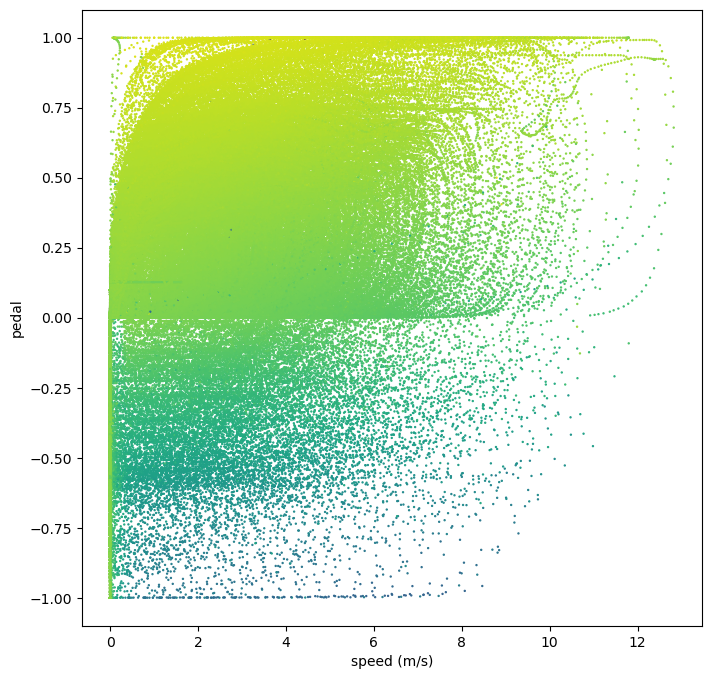

In [12]:
Y = ANALYSIS(X)

Y.plot_points()

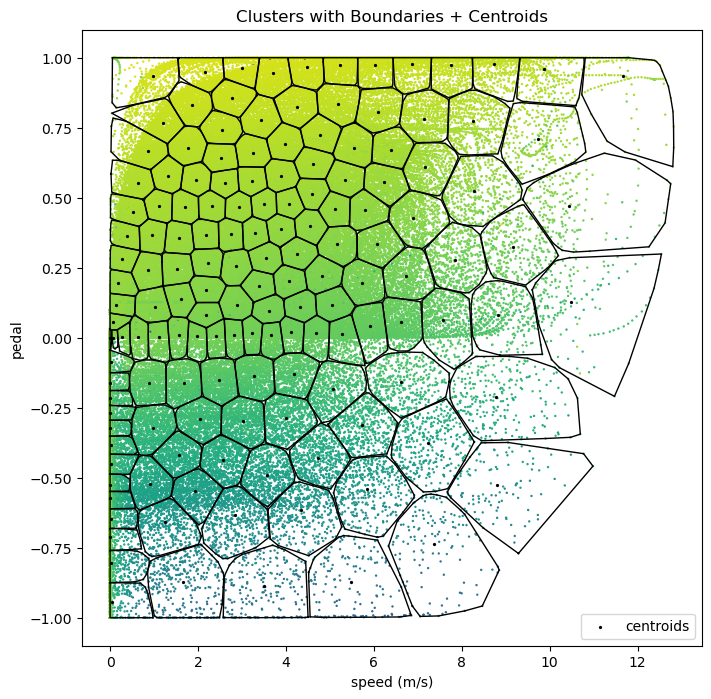

In [13]:
Y = ANALYSIS(X)

centroids = Y.kmeans_fit(n_clusters=150)
# print(centroids)
len(centroids)
Y.plot_points_kmeans()